# Exp 29 — Motion forensics for one clip

Clip: `data/octopus_clips_verified/2026-02-20/215423/Right_Front_0420-0440.mp4`
The pipeline flagged it with `mean_motion = 0.288` (threshold 0.12), but it looks static.
This notebook finds **what** is changing pixel-to-pixel, and why the score was high.


In [1]:
import json, subprocess, tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents]
               if (p/"data").exists() and (p/"weights").exists())
CLIP    = PROJECT/"data/octopus_clips_verified/2026-02-20/215423/Right_Front_0420-0440.mp4"
SRC_URL = "https://repo.octopus-intelligence.org/public/O-vulgaris-Nity-2026-2-20--/Right%20Front/Local/2026-02-20/215423--vv-1.mp4"
import sys as _sys
from pathlib import Path as _P
_root = next(p for p in [_P.cwd(), *_P.cwd().parents] if (p / 'server_creds.py').exists())
_sys.path.insert(0, str(_root))   # repo root, wherever this nb is run from
from server_creds import USER, PASS as PWD  # creds from env / .env, not hardcoded
WIN_START, WIN_END = 420, 440          # this clip's location in the source video
DBG = PROJECT/"data"/"motion_debug"; DBG.mkdir(parents=True, exist_ok=True)
print("clip exists:", CLIP.exists())

clip exists: True


In [2]:
# extract grayscale frames from the local 20s clip at high fps for detail
def extract_gray(src, fps):
    with tempfile.TemporaryDirectory() as t:
        subprocess.run(["ffmpeg","-loglevel","error","-i",str(src),
                        "-vf",f"fps={fps},format=gray","-q:v","2",f"{t}/f_%04d.jpg"],check=True)
        fs=sorted(Path(t).glob("f_*.jpg"))
        return np.stack([np.asarray(Image.open(f).convert("L"),dtype=np.float32) for f in fs])

CLIP_FPS = 5
G = extract_gray(CLIP, CLIP_FPS)        # (T, H, W)
print("clip frames:", G.shape, "@", CLIP_FPS, "fps   frame size:", G.shape[2], "x", G.shape[1])

clip frames: (100, 2160, 3840) @ 5 fps   frame size: 3840 x 2160


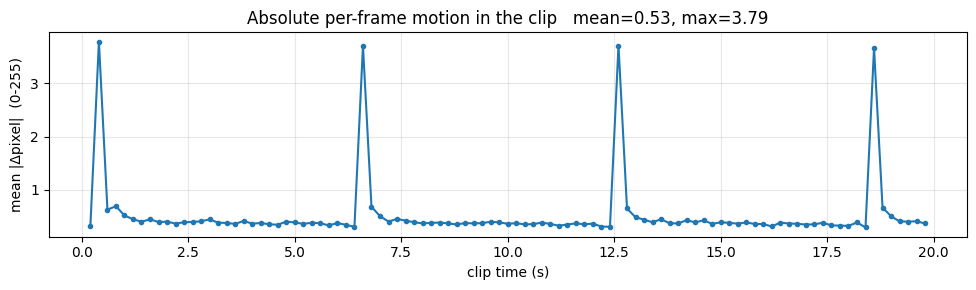

ABSOLUTE mean |Δ| across clip: 0.533 / 255  (0.21% brightness change)


In [3]:
# per-step ABSOLUTE motion (mean |delta pixel|, 0-255 scale)
diffs = np.abs(np.diff(G, axis=0))      # (T-1, H, W)
per_step = diffs.mean(axis=(1,2))
t = np.arange(1, len(G)) / CLIP_FPS
plt.figure(figsize=(10,3))
plt.plot(t, per_step, marker=".")
plt.xlabel("clip time (s)"); plt.ylabel("mean |Δpixel|  (0-255)")
plt.title(f"Absolute per-frame motion in the clip   mean={per_step.mean():.2f}, max={per_step.max():.2f}")
plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig(DBG/"per_frame_motion.png", dpi=110); plt.show()
print(f"ABSOLUTE mean |Δ| across clip: {per_step.mean():.3f} / 255  ({per_step.mean()/255*100:.2f}% brightness change)")

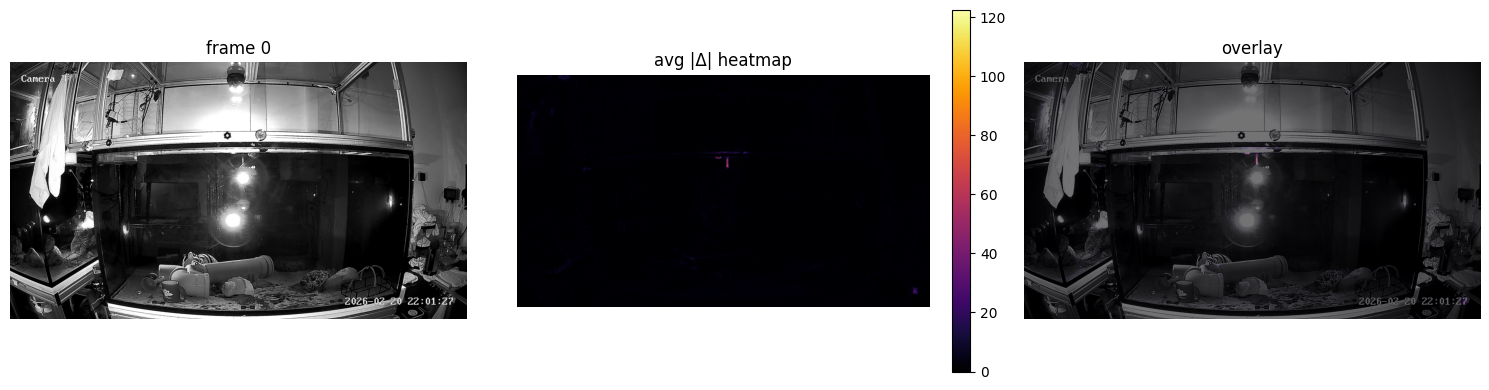

hottest pixel: x=0.51, y=0.39 (normalised)  value=122.5


In [4]:
# WHERE is the change? average |delta| per pixel -> heatmap
heat = diffs.mean(axis=0)               # (H, W)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(G[0], cmap="gray"); ax[0].set_title("frame 0"); ax[0].axis("off")
im = ax[1].imshow(heat, cmap="inferno"); ax[1].set_title("avg |Δ| heatmap"); ax[1].axis("off")
fig.colorbar(im, ax=ax[1], fraction=0.046)
ax[2].imshow(G[0], cmap="gray"); ax[2].imshow(heat, cmap="inferno", alpha=0.55)
ax[2].set_title("overlay"); ax[2].axis("off")
plt.tight_layout(); plt.savefig(DBG/"motion_heatmap.png", dpi=110); plt.show()

H, W = heat.shape
yx = np.unravel_index(np.argsort(heat, axis=None)[-1], heat.shape)
print(f"hottest pixel: x={yx[1]/W:.2f}, y={yx[0]/H:.2f} (normalised)  value={heat[yx]:.1f}")

In [5]:
# attribute the change: timestamp overlay (bottom-right) vs tank (center) vs whole frame
H, W = heat.shape
ts_corner = heat[int(H*0.88):, int(W*0.58):]                 # burned-in datetime
center    = heat[int(H*0.20):int(H*0.85), int(W*0.20):int(W*0.80)]
print(f"avg |Δ|  timestamp corner : {ts_corner.mean():6.2f}")
print(f"avg |Δ|  tank center      : {center.mean():6.2f}")
print(f"avg |Δ|  whole frame      : {heat.mean():6.2f}")
print(f"share of total change in timestamp corner: "
      f"{ts_corner.sum()/heat.sum()*100:.1f}% of pixels-change, "
      f"corner is {ts_corner.size/heat.size*100:.1f}% of area")

avg |Δ|  timestamp corner :   0.71
avg |Δ|  tank center      :   0.47
avg |Δ|  whole frame      :   0.53
share of total change in timestamp corner: 6.7% of pixels-change, corner is 5.1% of area


streaming full source video at 1fps (this takes ~30-60s)...


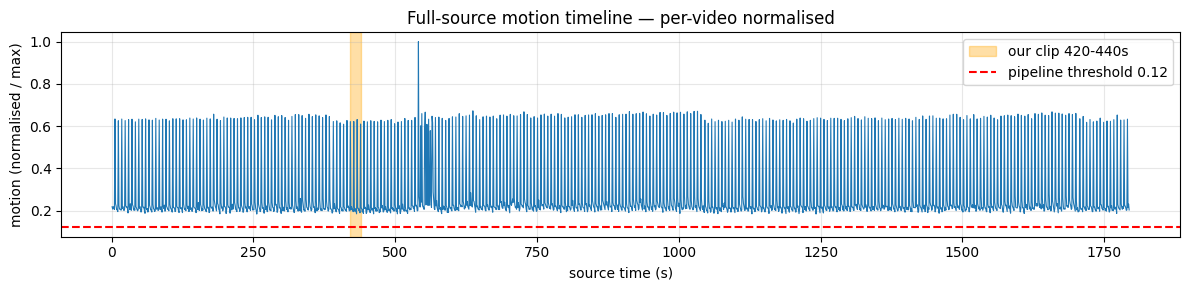

window mean NORMALISED motion: 0.287   (pipeline recorded 0.288)
window mean ABSOLUTE motion  : 0.36 / 255
source MAX absolute motion   : 1.24 / 255  at t=541s
source MEDIAN abs motion     : 0.27 / 255


In [6]:
# reproduce the pipeline: full-source per-second motion, normalised by the video's own max
def stream_gray_source(url, fps=1.0, size=224):
    auth=url.replace("https://", f"https://{USER}:{PWD}@")
    cmd=["ffmpeg","-loglevel","error","-i",auth,
         "-vf",f"fps={fps},scale={size}:{size},format=gray",
         "-f","image2pipe","-vcodec","rawvideo","-pix_fmt","gray","-"]
    p=subprocess.Popen(cmd,stdout=subprocess.PIPE,stderr=subprocess.PIPE)
    fsz=size*size; prev=None; ts=[]; mot=[]; i=0
    while True:
        raw=p.stdout.read(fsz)
        if len(raw)<fsz: break
        fr=np.frombuffer(raw,np.uint8).reshape(size,size).astype(np.int16)
        if prev is not None: mot.append(float(np.abs(fr-prev).mean())); ts.append(i)
        prev=fr; i+=1
    p.stdout.close(); p.wait()
    return np.array(ts), np.array(mot)

print("streaming full source video at 1fps (this takes ~30-60s)...")
ts, mot_abs = stream_gray_source(SRC_URL)
mot_norm = mot_abs/mot_abs.max() if mot_abs.max()>0 else mot_abs
plt.figure(figsize=(12,3))
plt.plot(ts, mot_norm, lw=0.8)
plt.axvspan(WIN_START, WIN_END, color="orange", alpha=0.35, label="our clip 420-440s")
plt.axhline(0.12, color="r", ls="--", label="pipeline threshold 0.12")
plt.xlabel("source time (s)"); plt.ylabel("motion (normalised / max)")
plt.title("Full-source motion timeline — per-video normalised"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(DBG/"source_motion_timeline.png", dpi=110); plt.show()

win=(ts>=WIN_START)&(ts<WIN_END)
print(f"window mean NORMALISED motion: {mot_norm[win].mean():.3f}   (pipeline recorded 0.288)")
print(f"window mean ABSOLUTE motion  : {mot_abs[win].mean():.2f} / 255")
print(f"source MAX absolute motion   : {mot_abs.max():.2f} / 255  at t={ts[int(mot_abs.argmax())]}s")
print(f"source MEDIAN abs motion     : {np.median(mot_abs):.2f} / 255")

## Reading the output
- **Absolute** mean |Δ| near 0 (a fraction of one grey level on 0–255) ⇒ visually static.
- The **heatmap** shows whether the change is the **timestamp overlay** ticking, global IR flicker, or the octopus.
- The **timeline** shows the clip's normalised value vs the 0.12 threshold: because motion is divided by the (also tiny) per-video max, a near-static window can still exceed 0.12.

**Likely conclusion:** the motion gate is *relative*, so on a quiet video trivial changes (timestamp digits / sensor flicker) get normalised up past the threshold. Fix = use an **absolute** motion floor, and/or mask the timestamp region.
